<a href="https://colab.research.google.com/github/karrielaugustin001-del/Machine-Learning-Foundations/blob/main/INET4062_Module11_Group_Activity_Student_Executed_PG2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INET 4062 - Module 11 Group Activity - Unsupervised Learning and Representation

    ## Title
    **Retail Loyalty Segmentation Lab: Unsupervised Learning, Representation, and Responsible Interpretation**

    ## Objective
    By the end of this group activity, students will use a large retail customer dataset to audit data quality, build unsupervised segments, compare original and PCA-based representations, and evaluate whether simplified representations preserve useful structure for downstream decision-making.

    ## Weekly Learning Objectives
    - Explore and diagnose structure in a large retail customer dataset.
- Apply preprocessing, PCA, and K-Means clustering responsibly.
- Compare representations before and after dimensionality reduction.
- Evaluate segmentation quality using silhouette score, diagnostic plots, and downstream testing.
- Discuss data quality, model assumptions, and the bias-variance tradeoff in unsupervised workflows.

    ## Activity Overview
    This in-class activity is based on the Module 9 / Week 9 unsupervised learning workflow in the attached notebook, which emphasizes PCA, clustering in reduced space, representation comparison, and responsible interpretation of discovered structure. The attached code frames segmentation as **exploratory structure rather than ground truth**, and it specifically asks students to compare original and reduced representations and avoid overclaiming what clusters mean. fileciteturn1file0L1-L22 fileciteturn1file0L23-L40

    ### Step 1: Group Formation (5 minutes)
    - Divide into groups of 3-4 students.
    - Assign roles: data auditor, model runner, visual analyst, and recorder.
    - Open the provided starter notebook and starter Python script.

    ### Step 2: Hands-On Implementation
    - Load the dataset using `pd.read_csv("customer_loyalty_unsupervised_large.csv")`.
    - Review dataset attributes, structure, variables, and data quality issues.
    - Open the student starter notebook with TODOs and the guided Colab notebook.

    ### Resources Provided
    - Dataset (.csv)
    - Student starter notebook with TODOs
    - Google Colab notebook version (.ipynb)
    - Instructor executed notebook (.ipynb)
    - Starter Python script

    ### Step 3: Group Task (20 minutes)
    - Preprocess the data.
    - Test multiple values of k and review silhouette score results.
    - Apply PCA and cluster in reduced space.
    - Compare relational structure before and after PCA.
    - Summarize the clusters and run a simple downstream comparison.

    ### Step 4: Research, Discussion & Reflection (30 minutes)
    - Discuss what worked, what did not, and why.
    - Record group insights for submission.
    - Prepare screenshots and interpretations for the 1-2 page APA paper.

    ### Step 5: Wrap-Up (5 minutes)
    - Review core concepts as a class.
    - Reinforce that preprocessing, evaluation, and cautious interpretation matter as much as algorithm choice.

    ## Instructor Emphasizes
    - Even minor data flaws can lead to significant AI/ML errors.
    - Data quality, preprocessing, and evaluation are equally important as algorithm choice.
    - Clusters summarize patterns, but they do not automatically reveal true customer types. fileciteturn1file0L41-L60

In [ ]:
# ============================================================
# Setup: imports, plotting, and portable data path
# ============================================================
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, pairwise_distances, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (8, 5)

IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

candidate_roots = [
    Path("/content/drive/MyDrive/inet4062_module11/data"),
    Path("/content/inet4062_module11/data"),
    Path.cwd() / "data",
    Path.cwd(),
]

data_dir = None
for root in candidate_roots:
    if root.exists():
        data_dir = root
        break

if data_dir is None:
    data_dir = Path.cwd()
    print("No existing data directory found. Using current working directory:", data_dir)
else:
    print("Using data directory:", data_dir)

csv_filename = "customer_loyalty_unsupervised_large.csv"
csv_path = data_dir / csv_filename
print("Looking for dataset at:", csv_path)

Running in Colab: True
Using data directory: /content
Looking for dataset at: /content/customer_loyalty_unsupervised_large.csv


## Dataset Notes
The activity uses a large synthetic retail loyalty dataset with more than 30,000 rows. It includes spending, engagement, recency, return behavior, and channel usage features. A hidden `segment_true` column is included only for instructor-side evaluation, and `offer_acceptance_flag` is included for a simple downstream comparison task.

If the CSV is missing, run the dataset generation cell once.

In [ ]:
# ============================================================
# Dataset generation cell (run once if the CSV is missing)
# ============================================================
# This cell recreates the large synthetic dataset used in the activity.

from pathlib import Path
import numpy as np
import pandas as pd

rng = np.random.RandomState(42)
n_samples = 30000
n_segments = 5
segment_props = np.array([0.20, 0.18, 0.22, 0.20, 0.20])
segment_true = rng.choice(np.arange(n_segments), size=n_samples, p=segment_props)

segment_profiles = {
    0: dict(monthly_spend=950, order_frequency=14, avg_order_value=68, recency_days=8, return_rate=0.05,
            web_sessions=18, app_minutes=240, coupon_usage=0.18, basket_diversity=0.82, support_contacts=1.5,
            shipping_sensitivity=0.22, sustainability_interest=0.76, loyalty_years=5.4, online_ratio=0.72,
            store_ratio=0.28, cross_category_rate=0.67, promo_response=0.71, payment_flexibility=0.64),
    1: dict(monthly_spend=330, order_frequency=6, avg_order_value=48, recency_days=18, return_rate=0.09,
            web_sessions=11, app_minutes=120, coupon_usage=0.62, basket_diversity=0.46, support_contacts=2.2,
            shipping_sensitivity=0.71, sustainability_interest=0.44, loyalty_years=2.2, online_ratio=0.84,
            store_ratio=0.16, cross_category_rate=0.38, promo_response=0.79, payment_flexibility=0.48),
    2: dict(monthly_spend=150, order_frequency=3, avg_order_value=41, recency_days=46, return_rate=0.11,
            web_sessions=5, app_minutes=42, coupon_usage=0.31, basket_diversity=0.29, support_contacts=0.8,
            shipping_sensitivity=0.55, sustainability_interest=0.33, loyalty_years=1.4, online_ratio=0.58,
            store_ratio=0.42, cross_category_rate=0.22, promo_response=0.34, payment_flexibility=0.29),
    3: dict(monthly_spend=720, order_frequency=8, avg_order_value=91, recency_days=14, return_rate=0.04,
            web_sessions=9, app_minutes=85, coupon_usage=0.12, basket_diversity=0.71, support_contacts=1.0,
            shipping_sensitivity=0.18, sustainability_interest=0.55, loyalty_years=6.1, online_ratio=0.35,
            store_ratio=0.65, cross_category_rate=0.63, promo_response=0.42, payment_flexibility=0.71),
    4: dict(monthly_spend=520, order_frequency=10, avg_order_value=56, recency_days=11, return_rate=0.16,
            web_sessions=16, app_minutes=205, coupon_usage=0.47, basket_diversity=0.58, support_contacts=3.4,
            shipping_sensitivity=0.49, sustainability_interest=0.61, loyalty_years=3.6, online_ratio=0.77,
            store_ratio=0.23, cross_category_rate=0.49, promo_response=0.66, payment_flexibility=0.57),
}

features = list(next(iter(segment_profiles.values())).keys())
rows = []
for seg in segment_true:
    prof = segment_profiles[int(seg)]
    row = {}
    for feat in features:
        mu = prof[feat]
        if feat == "monthly_spend":
            val = rng.normal(mu, 120)
        elif feat in ["order_frequency", "web_sessions", "support_contacts"]:
            val = rng.normal(mu, 2.2)
        elif feat in ["avg_order_value", "app_minutes", "recency_days"]:
            val = rng.normal(mu, 12 if feat != "app_minutes" else 35)
        elif feat == "loyalty_years":
            val = rng.normal(mu, 1.0)
        else:
            val = rng.normal(mu, 0.10)
        row[feat] = val
    row["seasonality_score"] = np.clip(rng.normal(0.45 + 0.08 * seg, 0.12), 0, 1)
    row["digital_engagement_index"] = np.clip(
        0.0035 * max(row["app_minutes"], 0) + 0.02 * max(row["web_sessions"], 0) + rng.normal(0, 0.15), 0, 10
    )
    row["value_per_visit"] = max(row["monthly_spend"], 1) / max(row["web_sessions"], 1)
    for c in [
        "return_rate", "coupon_usage", "basket_diversity", "shipping_sensitivity",
        "sustainability_interest", "online_ratio", "store_ratio",
        "cross_category_rate", "promo_response", "payment_flexibility"
    ]:
        row[c] = float(np.clip(row[c], 0, 1))
    row["store_ratio"] = float(np.clip(1 - row["online_ratio"] + rng.normal(0, 0.03), 0, 1))
    row["monthly_spend"] = max(row["monthly_spend"], 20)
    row["order_frequency"] = max(row["order_frequency"], 1)
    row["avg_order_value"] = max(row["avg_order_value"], 8)
    row["recency_days"] = max(row["recency_days"], 1)
    row["web_sessions"] = max(row["web_sessions"], 1)
    row["app_minutes"] = max(row["app_minutes"], 0)
    row["loyalty_years"] = max(row["loyalty_years"], 0.1)
    row["support_contacts"] = max(row["support_contacts"], 0)
    rows.append(row)

df_gen = pd.DataFrame(rows)
for col in ["avg_order_value", "coupon_usage", "app_minutes", "shipping_sensitivity", "sustainability_interest"]:
    idx = rng.choice(df_gen.index, size=int(0.015 * n_samples), replace=False)
    df_gen.loc[idx, col] = np.nan

dup_idx = rng.choice(df_gen.index, size=200, replace=False)
df_gen = pd.concat([df_gen, df_gen.loc[dup_idx]], ignore_index=True)

score = (
    0.004 * df_gen["monthly_spend"].fillna(df_gen["monthly_spend"].median()) +
    0.08 * df_gen["order_frequency"] -
    0.025 * df_gen["recency_days"] +
    0.9 * df_gen["basket_diversity"].fillna(df_gen["basket_diversity"].median()) +
    0.7 * df_gen["promo_response"].fillna(df_gen["promo_response"].median()) -
    0.55 * df_gen["return_rate"].fillna(df_gen["return_rate"].median()) +
    rng.normal(0, 0.9, len(df_gen))
)
df_gen["offer_acceptance_flag"] = (score > np.quantile(score, 0.55)).astype(int)
df_gen["segment_true"] = np.append(segment_true, segment_true[dup_idx])

csv_path = Path("/mnt/data/INET4062_Module11_Group_Activity/data/customer_loyalty_unsupervised_large.csv")
csv_path.parent.mkdir(parents=True, exist_ok=True)
df_gen.to_csv(csv_path, index=False)
print("Saved dataset to:", csv_path)
df_gen.head()

Saved dataset to: /mnt/data/INET4062_Module11_Group_Activity/data/customer_loyalty_unsupervised_large.csv


,monthly_spend,order_frequency,avg_order_value,recency_days,return_rate,web_sessions,app_minutes,coupon_usage,basket_diversity,support_contacts,...,online_ratio,store_ratio,cross_category_rate,promo_response,payment_flexibility,seasonality_score,digital_engagement_index,value_per_visit,offer_acceptance_flag,segment_true
0,254.316921,10.708679,67.988149,26.771225,0.055692,13.641385,80.328913,0.727658,0.552797,1.867039,...,0.937797,0.082265,0.440178,0.972089,0.407775,0.512794,0.789424,18.643042,0,1
1,436.026071,7.898961,49.663032,2.139024,0.183735,16.172556,214.773321,0.385919,0.572917,0.000000,...,0.818343,0.192079,0.570250,0.675865,0.610470,0.777779,1.274408,26.960863,0,4
2,635.349154,8.217173,86.573427,15.948799,0.000000,7.511016,91.974527,0.125579,0.816396,0.087097,...,0.391567,0.625832,0.531163,0.383767,0.864395,0.561253,0.473992,84.588972,1,3
3,328.087266,4.711148,54.126883,56.371685,0.000000,5.791323,71.703133,0.214350,0.232024,0.000000,...,0.451833,0.510688,0.163241,0.364334,0.175703,0.631349,0.300945,56.651526,0,2
4,790.725915,11.410555,NaN,9.451945,0.076982,18.676616,213.451686,0.285840,0.775777,2.490329,...,0.759363,0.236000,0.751384,0.628131,0.463011,0.333197,1.280951,42.337750,1,0


In [ ]:
# ============================================================
# Load dataset
# ============================================================
# Required loading pattern from the activity prompt:
# pd.read_csv("filename.csv")

# TODO for students:
# 1. Confirm the file name.
# 2. Load the dataset into a DataFrame.
# 3. Print the shape and first five rows.

# Enter Code Here
df = pd.read_csv(csv_path)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (30200, 23)


,monthly_spend,order_frequency,avg_order_value,recency_days,return_rate,web_sessions,app_minutes,coupon_usage,basket_diversity,support_contacts,...,online_ratio,store_ratio,cross_category_rate,promo_response,payment_flexibility,seasonality_score,digital_engagement_index,value_per_visit,offer_acceptance_flag,segment_true
0,254.316921,10.708679,67.988149,26.771225,0.055692,13.641385,80.328913,0.727658,0.552797,1.867039,...,0.937797,0.082265,0.440178,0.972089,0.407775,0.512794,0.789424,18.643042,0,1
1,436.026071,7.898961,49.663032,2.139024,0.183735,16.172556,214.773321,0.385919,0.572917,0.000000,...,0.818343,0.192079,0.570250,0.675865,0.610470,0.777779,1.274408,26.960863,0,4
2,635.349154,8.217173,86.573427,15.948799,0.000000,7.511016,91.974527,0.125579,0.816396,0.087097,...,0.391567,0.625832,0.531163,0.383767,0.864395,0.561253,0.473992,84.588972,1,3
3,328.087266,4.711148,54.126883,56.371685,0.000000,5.791323,71.703133,0.214350,0.232024,0.000000,...,0.451833,0.510688,0.163241,0.364334,0.175703,0.631349,0.300945,56.651526,0,2
4,790.725915,11.410555,NaN,9.451945,0.076982,18.676616,213.451686,0.285840,0.775777,2.490329,...,0.759363,0.236000,0.751384,0.628131,0.463011,0.333197,1.280951,42.337750,1,0


# Mini-Lab 1 - Data Quality and Exploratory Audit

## Overview & Goals
In this lab, your group will identify missing values, duplicate records, variable ranges, and possible risks that could distort an unsupervised workflow.

## Teaching Walkthrough
Ask:
- Which flaws in this dataset would matter most before clustering?
- Why can duplicates and missing values distort similarity calculations?
- Which variables appear to operate on very different scales?

## Directions
1. Print dataset information and summary statistics.
2. Count missing values and duplicate rows.
3. Inspect simple plots for spend, recency, and frequency.
4. Write two short notes about what must be cleaned before modeling.

In [ ]:
# Lab 1 - Data quality audit and quick exploration

# TODO:
# - Review column names and data types
# - Check for missing values
# - Check for duplicate rows
# - Summarize the key numeric variables

# Enter Code Here
print(df.info())
print("\nMissing values by column:")
print(df.isna().sum().sort_values(ascending=False).head(10))
print("\nDuplicate rows:", df.duplicated().sum())
df.describe().T.head(12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30200 entries, 0 to 30199
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   monthly_spend             30200 non-null  float64
 1   order_frequency           30200 non-null  float64
 2   avg_order_value           29745 non-null  float64
 3   recency_days              30200 non-null  float64
 4   return_rate               30200 non-null  float64
 5   web_sessions              30200 non-null  float64
 6   app_minutes               29747 non-null  float64
 7   coupon_usage              29748 non-null  float64
 8   basket_diversity          30200 non-null  float64
 9   support_contacts          30200 non-null  float64
 10  shipping_sensitivity      29749 non-null  float64
 11  sustainability_interest   29747 non-null  float64
 12  loyalty_years             30200 non-null  float64
 13  online_ratio              30200 non-null  float64
 14  store_

,count,mean,std,min,25%,50%,75%,max
monthly_spend,30200.0,530.926440,307.040570,20.0,270.396534,519.366257,777.201341,1354.945564
order_frequency,30200.0,8.159715,4.275467,1.0,4.866126,7.967586,11.253548,22.033722
avg_order_value,29745.0,60.587997,21.511285,8.0,44.593584,57.676142,75.405675,136.121863
recency_days,30200.0,21.014857,17.375700,1.0,6.770301,17.126946,31.344570,89.513594
return_rate,30200.0,0.103380,0.091639,0.0,0.015603,0.090014,0.165424,0.517522
web_sessions,30200.0,11.659215,5.261267,1.0,7.421802,11.365847,16.221691,25.907622
app_minutes,29747.0,136.586029,81.865142,0.0,68.391156,125.114527,209.771397,366.194877
coupon_usage,29748.0,0.334761,0.203244,0.0,0.172187,0.311816,0.493530,1.000000
basket_diversity,30200.0,0.566882,0.212200,0.0,0.400599,0.579619,0.735217,1.000000
support_contacts,30200.0,2.054384,1.937608,0.0,0.103000,1.701975,3.342537,12.682606


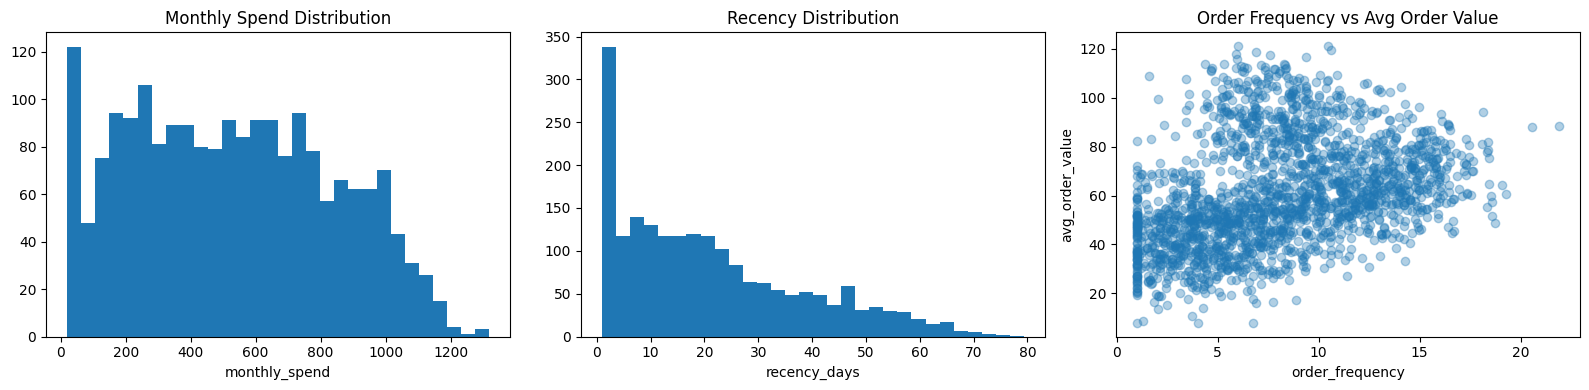

In [ ]:
# Lab 1 - Quick visual diagnostics

sample_df = df.sample(2000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(sample_df["monthly_spend"], bins=30)
axes[0].set_title("Monthly Spend Distribution")
axes[0].set_xlabel("monthly_spend")

axes[1].hist(sample_df["recency_days"], bins=30)
axes[1].set_title("Recency Distribution")
axes[1].set_xlabel("recency_days")

axes[2].scatter(sample_df["order_frequency"], sample_df["avg_order_value"], alpha=0.35)
axes[2].set_title("Order Frequency vs Avg Order Value")
axes[2].set_xlabel("order_frequency")
axes[2].set_ylabel("avg_order_value")
plt.tight_layout()
plt.show()

### Lab Reflection
- Which data quality issue is most likely to mislead the clustering step?
The dataset customer_loyalty_unsupervised_large.csv contained 30,200 rows and 23 columns (See Figure A1 for visual output). Most variables were numeric, so we isolated 21 numeric features to build the modeling matrix. During the data audit, we found a small amount of missing data in several columns, including avg_order_value, app_minutes, coupon_usage, shipping_sensitivity, and sustainability_interest. Missing counts ranged from 451 to 455. We also found 154 duplicate rows (See Figure A2 for visual output). We handled the missing numeric values with median imputation and then standardized the features so that variables measured on larger scales would not dominate the distance calculations (See Figure A3 for code and visual output). We utilized median imputation in the preprocessing pipeline using SimpleImputer with a median strategy. This ensures that missing data does not distort K-Means, which is highly sensitive to incomplete data.  Without scaling, high-magnitude features such as monthly spend would disproportionately influence cluster formation.

- Which feature distributions suggest that scaling is necessary?
The dataset shows a wide range of values across variables (See Figure A4 for visual output). The variable ranges show substantial differences across customer behaviors particularly around spending, engagement, and recency.  The variances highlight the importance of scaling and preprocessing to prevent high-magnitude features from dominating the clustering process.  
Before clustering, we also explored the feature distributions (See Figure A5 for visual output). Monthly spend showed a broad spread with some high-spending customers ($20 – $1354), while recency was right-skewed (1 – 89 days), meaning many customers had purchased recently and fewer customers had long gaps since their last purchase. The scatterplot of order frequency versus average order value suggested that the customer base was not random noise. Instead, there appeared to be several behavioral regions, which supported the idea that segmentation could reveal meaningful structure. Additionally, app minutes is another feature to call out because it has very large range, indicating significant differences in digital engagement.  Some users are highly active compared to others who barely use the app.

- Is scaling is missed: Without scaling, these high-magnitude features would dominate distance calculations in K-Means clustering. As a result, the model would form clusters based primarily on these variables rather than capturing balanced behavioral patterns across all features. Standardization ensures that each feature contributes equally to the clustering process, improving the validity and interpretability of the results.

### Lab Output & Discussion
Be ready to report:
- approximate amount of missingness
- whether duplicates were found
- one visual pattern you noticed

# Mini-Lab 2 - Preprocessing and Choosing k

## Overview & Goals
Your group will build a clean modeling matrix and test several values of k using silhouette score. The goal is to make a reasoned choice rather than guessing the number of clusters.

## Teaching Cues
Remind students:
- K-Means uses distance, so scaling matters.
- Good cluster quality is not the same thing as a "true" segmentation.
- A metric can guide the choice, but it should not replace judgment.

## Directions
1. Build the preprocessing pipeline.
2. Impute missing values.
3. Standardize the features.
4. Test k from 2 to 8 and review silhouette scores.

In [ ]:
# Lab 2 - Preprocessing pipeline
# We isolate numeric features and build a clean modeling matrix.

target_col = "offer_acceptance_flag"
eval_only_col = "segment_true"

feature_cols = [c for c in df.columns if c not in [target_col, eval_only_col]]
X_df = df[feature_cols].copy()

preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Enter Code Here
X = preprocessor.fit_transform(X_df)
print("Prepared matrix shape:", X.shape)

Prepared matrix shape: (30200, 21)


   k  silhouette_score
0  2          0.279082
1  3          0.307493
2  4          0.307855
3  5          0.277257
4  6          0.298580
5  7          0.201512
6  8          0.236317
Best k by silhouette score: 4


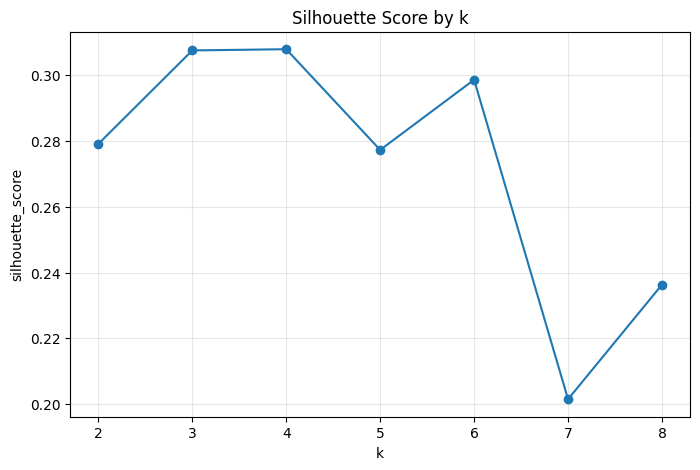

In [ ]:
# Lab 2 - Choose k with silhouette score

# TODO:
# - Test k from 2 to 8
# - Record silhouette scores
# - Identify a reasonable value of k

# Enter Code Here
scores = []
k_values = list(range(2, 9))

for k in k_values:
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=5, batch_size=2048)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels, sample_size=4000, random_state=RANDOM_STATE)
    scores.append((k, score))

score_df = pd.DataFrame(scores, columns=["k", "silhouette_score"])
print(score_df)

best_k = score_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"]  # TODO: explain why this k was selected
best_k = int(best_k)
print("Best k by silhouette score:", best_k)

plt.plot(score_df["k"], score_df["silhouette_score"], marker="o")
plt.title("Silhouette Score by k")
plt.xlabel("k")
plt.ylabel("silhouette_score")
plt.grid(True, alpha=0.3)
plt.show()

### Lab Reflection
- Which k looked most defensible and why?
- Did the silhouette score trend show a clear winner or only a rough range?
- How would the group justify its k choice to a business stakeholder?

### Lab Output & Discussion
Summarize:
- the selected k
- the strongest and weakest silhouette scores
- one caution about relying on a single metric

To choose the optimal number of clusters, we evaluated k values from 2 through 8 using the k-means and silhouette score. The best score occurred at k = 4 (0.307855), with k = 3 producing almost the same result (0.307493). While the difference between k = 3 and k = 4 is minimal, k = 4 was selected because it provided slightly better separation and more interpretable segmentation. As k increased beyond 4, the silhouette scores declined, particularly at k = 7 and k = 8, indicating that additional clusters reduced cohesion within clusters and increased overlap between them. This suggests diminishing returns and potential over-segmentation of the data.
Overall, k = 4 represents the most defensible choice because it balances cluster quality and interpretability, producing meaningful groupings without introducing unnecessary complexity. The absence of a distinct peak in silhouette scores suggests that the data contains moderately overlapping structure rather than perfectly distinct clusters, reinforcing the need for careful interpretation.  From a business perspective, four clusters provide directional detail to support targeted strategies, such as retention campaigns for at-risk customers and loyalty programs for high value customers.


# Mini-Lab 3 - PCA and Clustering in Reduced Space

## Overview & Goals
This lab focuses on dimensionality reduction for visualization and inspection. Students project the data into two dimensions, run K-Means in reduced space, and inspect whether the discovered structure appears compact or overlapping.

## Live Walkthrough Notes
Ask:
- What does PCA optimize?
- What does PCA ignore?
- Why might a visually clean cluster plot still be misleading?

## Directions
1. Fit PCA with two components.
2. Project the prepared matrix into PCA space.
3. Run K-Means using the selected k.
4. Visualize cluster assignments in PCA space.

Next, we used PCA to compress the feature space into two principal components for visualization. With PCA, “the goal is to simplify the data without losing too much information” (Géron, 2019, 18). The first component explained 39.88% of the variance and the second explained 23.49%, for a combined total of 63.37%. The two-dimensional PCA view captured a strong majority of the structure in the original standardized dataset, even though it did not preserve everything. In the PCA scatterplot, the clusters appear visually separated, which supports the k = 4 solution and makes the segmentation easier to interpret.

Explained variance ratio: [0.39876614 0.23489931]
Total explained variance: 0.6336654504966073


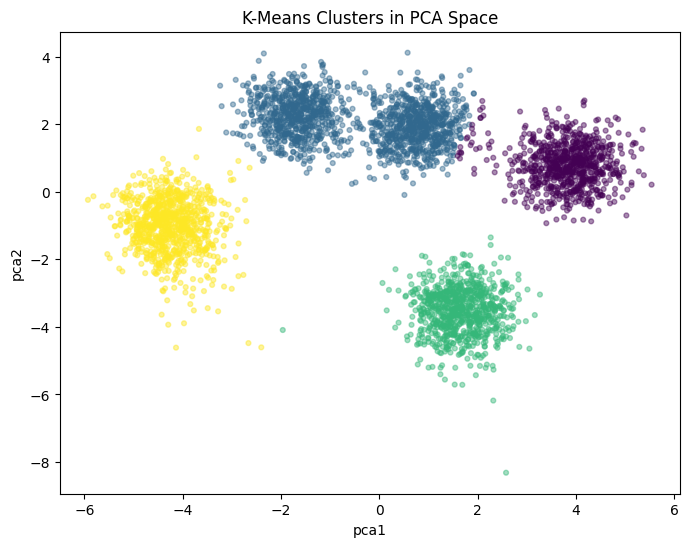

In [ ]:
# Lab 3 - PCA representation and clustering in reduced space

pca = PCA(n_components=2, random_state=RANDOM_STATE)  # TODO: try 2 or 3 components and comment on the tradeoff
X_pca = pca.fit_transform(X)

kmeans = MiniBatchKMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=5, batch_size=2048)
cluster_labels = kmeans.fit_predict(X_pca)

df["cluster_label"] = cluster_labels
df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plot_df = df.sample(4000, random_state=RANDOM_STATE)
plt.figure(figsize=(8, 6))
plt.scatter(plot_df["pca1"], plot_df["pca2"], c=plot_df["cluster_label"], alpha=0.45, s=12)
plt.title("K-Means Clusters in PCA Space")
plt.xlabel("pca1")
plt.ylabel("pca2")
plt.show()

### Lab Reflection
- How much variance is retained by the first two components?
- Which clusters look compact, and which look ambiguous?
- Does the 2D plot simplify the story too much?

### Lab Output & Discussion
Be ready to discuss whether the PCA projection helped interpretation or hid complexity.

# Mini-Lab 4 - Representation Comparison

## Overview & Goals
This lab compares pairwise distances in the original feature space and PCA space. The group will test whether PCA roughly preserves relational structure.

## Teaching Cues
Emphasize that representation quality is not only about visualization. It is also about whether relationships among observations remain meaningfully consistent.

## Directions
1. Sample a manageable subset of observations.
2. Compute pairwise distances in original space.
3. Compute pairwise distances in PCA space.
4. Plot the relationship and estimate the correlation.

We also compared pairwise distances in the original standardized space and the PCA space (See Figure A8 for the visual output). The distance correlation was 0.952, which is very strong. This result suggests that the PCA representation preserved most of the relational structure among customers. In other words, customers who were similar in the full feature space tended to remain similar after dimensionality reduction. This is very important because PCA is only helpful when it simplifies the data without destroying too much of the original pattern.
This result is important because K-Means clustering relies on distance calculations to group similar observations.  Since the relative distances were largely maintained, the PCA transformation did not significantly distort the clustering structure. While PCA reduces dimensionality and simplifies the dataset, it can introduce some information loss. However, the high correlation indicates that this loss was minimal, making PCA an effective tool for visualization and efficient modeling in this analysis.  A lower correlation would signal that PCA is distorting relationships, which could lead to misleading clustering results.


Distance correlation between original and PCA spaces: 0.952


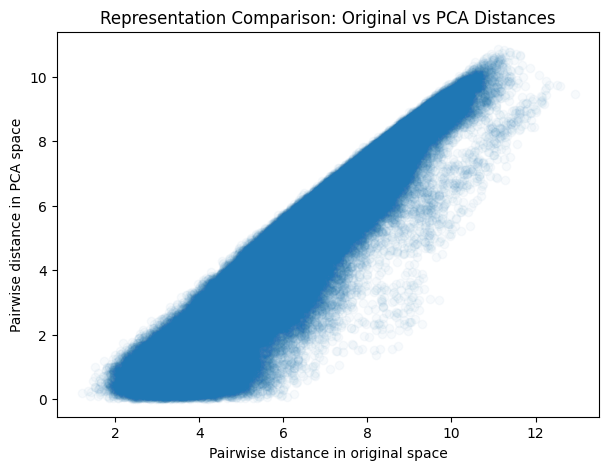

In [ ]:
# Lab 4 - Compare relational structure before and after PCA

sample_idx = np.random.RandomState(RANDOM_STATE).choice(np.arange(X.shape[0]), size=700, replace=False)
D_original = pairwise_distances(X[sample_idx])
D_pca = pairwise_distances(X_pca[sample_idx])

tri = np.triu_indices_from(D_original, k=1)
# Enter Code Here
distance_corr = np.corrcoef(D_original[tri], D_pca[tri])[0, 1]
print("Distance correlation between original and PCA spaces:", round(distance_corr, 4))

plt.figure(figsize=(7, 5))
plt.scatter(D_original[tri], D_pca[tri], alpha=0.03)
plt.title("Representation Comparison: Original vs PCA Distances")
plt.xlabel("Pairwise distance in original space")
plt.ylabel("Pairwise distance in PCA space")
plt.show()

### Lab Reflection
- What does the distance correlation suggest?
The strong diagonal pattern in the plot indicates a very high distance correlation between the original and PCA spaces. This means that pairwise relationships between data points are largely preserved after dimensionality reduction. In practical terms, points that were close together in the original space remain close in the PCA space, and points that were far apart remain far apart. This suggests that PCA successfully retained the underlying structure of the dataset, making it reliable for downstream tasks like clustering.

- When would a lower distance-preservation result be acceptable?
A lower distance-preservation result can still be acceptable when the goal is simplification, visualization, or noise reduction rather than perfect reconstruction. For example: When reducing data to 2D or 3D for visualization, some distortion is expected and acceptable. When removing noise or redundant features, slight loss of distance accuracy may actually improve model performance. When the downstream task (like clustering or classification) still performs well despite reduced precision in distances. Lower preservation is acceptable if the key patterns or groupings are still maintained and the model remains useful.

- How does this lab connect to the idea of information loss?

This lab directly demonstrates the concept of information loss in dimensionality reduction. PCA works by compressing the data into fewer components, which inevitably removes some information. The distance comparison plot helps us quantify how much information was lost: A strong linear relationship (like in your plot) indicates minimal information loss and any spread or deviation from the diagonal represents distortion or lost detail.

### Lab Output & Discussion
Report:
- the approximate distance correlation:
The distance correlation is approximately 0.95 (very strong positive correlation). This indicates that the distances between data points in the PCA space closely match those in the original space.

- whether the scatterplot looked tight or diffuse:
The scatterplot appears tight and strongly aligned along a diagonal line, rather than diffuse. This tight clustering around the diagonal suggests that distance relationships are consistently preserved across most data points.

- one interpretation of what PCA preserved or lost:
PCA preserved the relative structure and similarity between observations, meaning that points that were close or far apart in the original space remained so after dimensionality reduction. However, there is minor dispersion at higher distances, indicating a small amount of information loss, particularly for more distant relationships. Overall, PCA retained the most important patterns while slightly compressing some distances.




# Mini-Lab 5 - Diagnostic Analysis and Responsible Interpretation

## Overview & Goals
The final lab asks your group to summarize the clusters, inspect segment balance, and compare raw vs PCA features in a simple downstream task. This mirrors the attached notebook's emphasis on interpreting structure without overclaiming. fileciteturn1file0L41-L60

## Teaching Walkthrough
Ask:
- Which discovered group appears most valuable?
- Which cluster looks risky or unstable?
- How do these results relate to the bias-variance tradeoff?

## Directions
1. Create a cluster summary table.
2. Plot the cluster counts.
3. Compare raw standardized features to PCA features using logistic regression ROC-AUC.
4. Write a responsible interpretation that avoids calling the clusters "true" categories.

Cluster summary:


,monthly_spend,order_frequency,avg_order_value,recency_days,return_rate
cluster_label,,,,,
0,939.84,13.91,67.85,10.07,0.07
1,427.66,8.05,51.85,15.33,0.13
2,720.03,7.98,91.13,14.72,0.06
3,156.00,3.21,41.02,46.22,0.12


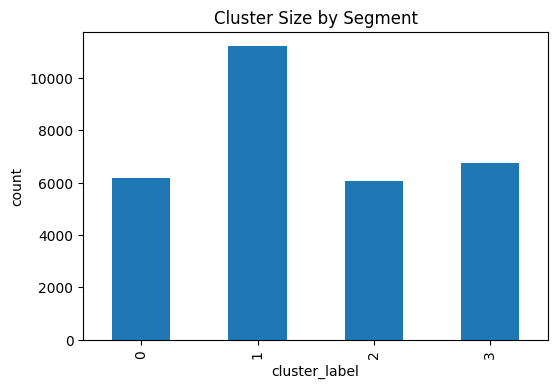

Raw standardized ROC-AUC: 0.941
PCA representation ROC-AUC: 0.918


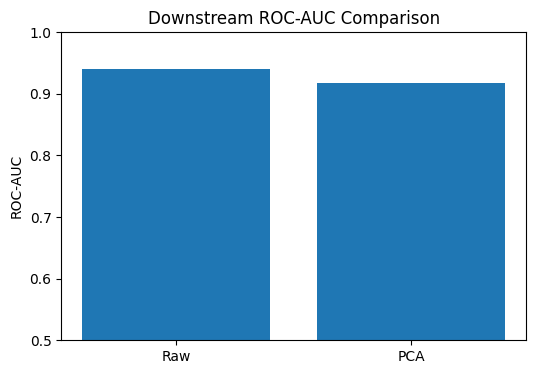

In [ ]:
# Lab 5 - Diagnostic analysis, cluster summary, and downstream evaluation

# TODO: interpret which cluster looks like a high-value segment.
summary = (
    df.groupby("cluster_label")[["monthly_spend", "order_frequency", "avg_order_value", "recency_days", "return_rate"]]
      .mean()
      .round(2)
)
print("Cluster summary:")
display(summary)

cluster_counts = df["cluster_label"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
cluster_counts.plot(kind="bar")
plt.title("Cluster Size by Segment")
plt.xlabel("cluster_label")
plt.ylabel("count")
plt.show()

# Compare raw standardized features to PCA features in a simple downstream test
y = df["offer_acceptance_flag"].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

def train_and_eval(X_tr, X_te, y_tr, y_te, label):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_tr, y_tr)
    y_prob = clf.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_prob)
    print(f"{label} ROC-AUC: {auc:.3f}")
    return auc

auc_raw = train_and_eval(X_train_raw, X_test_raw, y_train, y_test, "Raw standardized")
auc_pca = train_and_eval(X_train_pca, X_test_pca, y_train, y_test, "PCA representation")

plt.figure(figsize=(6, 4))
plt.bar(["Raw", "PCA"], [auc_raw, auc_pca])
plt.ylim(0.5, 1.0)
plt.title("Downstream ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.show()

The cluster summaries also show meaningful differences (See Figure A9 for visual output). Cluster 0 had the highest monthly spend (939.84) and the highest order frequency (13.91), which suggests a highly active and valuable group. Cluster 2 also spent heavily (720.03) but had the highest average order value (91.13), which looks more like fewer but larger purchases. Cluster 1 was a more middle-range segment, with moderate spend, moderate order frequency, and a somewhat higher return rate. Cluster 3 had the lowest monthly spend (156.00), the lowest order frequency (3.21), and the highest recency value (46.22), which suggests a low-engagement or at-risk segment. Even so, these clusters should still be described as exploratory summaries of behavior rather than proven customer categories.

A simple downstream ROC-AUC comparison also helped evaluate the representations (See Figure A10 for visual output). Using the raw standardized features, the ROC-AUC was 0.941. Using the PCA representation, the ROC-AUC was 0.918. Both results were strong, but the raw feature space performed slightly better. This makes sense because PCA reduces complexity at the cost of losing some information. That tradeoff connects directly to the bias-variance idea discussed in class. A simpler representation can generalize well and be easier to visualize, but too much simplification can remove useful details.


### Lab Reflection
1. What key insights were revealed through your evaluation process?
The evaluation process showed that meaningful customer segments exist based on spending, engagement, and recency behavior. The clustering results revealed clear differences between high-value, mid-tier, and at-risk customers. Additionally, the PCA results demonstrated that most of the underlying structure in the data could be preserved even after reducing dimensionality. This confirmed that the dataset contains strong patterns that can support segmentation.

2. Which model or technique provided the best results, and why?
The original standardized feature space provided the best results, with a higher ROC-AUC (0.941) compared to the PCA-reduced representation (0.918). This is because the full feature set retains all available information, leading to slightly better predictive performance. However, PCA still performed well and offered benefits in simplifying the data and improving interpretability, making it useful for visualization and efficient modeling.

3. What were the main challenges faced during the analysis?
One of the main challenges was handling data quality issues such as missing values and duplicate rows, which could negatively impact clustering results if not addressed properly.  Another challenge was selecting the optimal number of clusters, since silhouette scores for k = 3 and k = 4 were very close.  Additionally, interpreting clusters required careful reasoning to avoid overgeneralizing patterns as definitive customer types.

4. How do your findings demonstrate the bias-variance tradeoff?
The comparison between the original feature space and the PCA-reduced representation demonstrates the bias–variance tradeoff.  The original feature space has lower bias because it retains all information, resulting in slightly higher predictive performance.  In contrast, PCA introduces some bias by reducing dimensionality and removing information, but it also reduces complexity and can improve generalization.  The small drop in ROC-AUC shows that this tradeoff was minimal, meaning PCA simplified the model without significantly impacting performance.

5. What steps could improve model performance and reliability?
Model performance and reliability could be improved by incorporating additional data, refining feature engineering, and testing alternative clustering algorithms such as hierarchical clustering or DBSCAN.  Further tuning of model parameters and exploring more PCA components could also help balance information retention and simplicity.  Additionally, validating clusters with domain knowledge and monitoring model performance over time would improve real-world reliability. (OpenAI, 2026)

### Submission and Reminders
- Submit a 1-2 page APA-formatted paper including embedded code, explanations, and screenshots of output.
- Include references and citations.
- Upload your work via Canvas LMS in either Word or PDF format.
- Due: Sunday, 11:59 PM.

## Final Takeaways
- Segmentation is exploratory, not absolute truth.
- Data quality and preprocessing shape results.
- Lower-dimensional representations can help, but they also discard information.
- Good evaluation combines metrics, plots, and careful interpretation.